<a href="https://colab.research.google.com/github/paradox-shivansh/CRUW-Bearing/blob/main/bearing_fault_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bearing Fault Classification — EDA & Machine Learning

This notebook takes a CSV of statistical vibration features (`max`, `min`, `mean`, `sd`, `rms`,
`skewness`, `kurtosis`, `crest`, `form`) and a label column (`fault`) describing the bearing
condition (e.g. `Ball_007_1`, `Normal`, `IR_014_2`, ...), and:

1. Loads and explores the data (EDA)
2. Prepares it for machine learning
3. Trains several supervised classification models and compares them
4. Takes the **best** model and validates it properly with **k-fold cross-validation**
5. Produces the key graphs and metrics needed to judge the result
6. Ends with a plain-language summary

> **Before running:** put your CSV file in the same folder as this notebook and set
> `DATA_PATH` in the cell below (default: `data.csv`).


In [1]:
# --- Setup: imports & config ---
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

# ---- CONFIG: change this if your file has a different name/path ----
DATA_PATH = "data.csv"
TARGET_COLUMN = "fault"   # the column we want to predict


## 1. Load the data

In [2]:
df = pd.read_csv("feature_time_48k_2048_load_1.csv")
print("Shape:", df.shape)
df.head()


Shape: (2300, 10)


,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2300 entries, 0 to 2299
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   max       2300 non-null   float64
 1   min       2300 non-null   float64
 2   mean      2300 non-null   float64
 3   sd        2300 non-null   float64
 4   rms       2300 non-null   float64
 5   skewness  2300 non-null   float64
 6   kurtosis  2300 non-null   float64
 7   crest     2300 non-null   float64
 8   form      2300 non-null   float64
 9   fault     2300 non-null   object 
dtypes: float64(9), object(1)
memory usage: 179.8+ KB


In [4]:
# Basic sanity checks
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
max         0
min         0
mean        0
sd          0
rms         0
skewness    0
kurtosis    0
crest       0
form        0
fault       0
dtype: int64

Duplicate rows: 0


In [5]:
# Drop exact duplicate rows (if any) and rows with missing target
df = df.drop_duplicates()
df = df.dropna(subset=[TARGET_COLUMN])
print("Shape after cleaning:", df.shape)


Shape after cleaning: (2300, 10)


## 2. Exploratory Data Analysis (EDA)

We look at:
- How many classes (fault types) we have and whether they're balanced
- The distribution of each numeric feature
- Whether features differ across fault classes
- How features correlate with each other


### 2.1 Class balance

fault
Ball_007_1    230
Ball_014_1    230
Ball_021_1    230
IR_007_1      230
IR_014_1      230
IR_021_1      230
OR_007_6_1    230
OR_014_6_1    230
OR_021_6_1    230
Normal_1      230
Name: count, dtype: int64


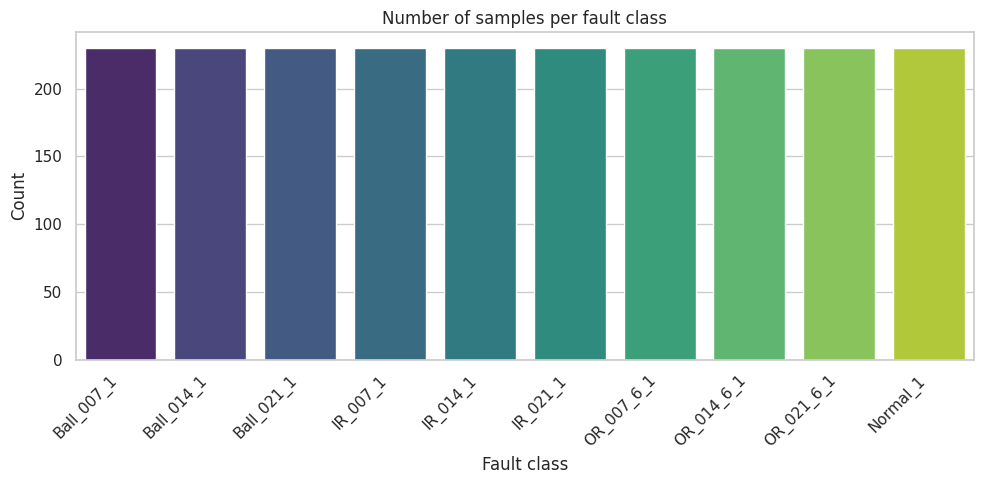

In [6]:
class_counts = df[TARGET_COLUMN].value_counts()
print(class_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Number of samples per fault class")
plt.xlabel("Fault class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 2.2 Feature distributions

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric feature columns:", numeric_cols)

df[numeric_cols].describe().T


Numeric feature columns: ['max', 'min', 'mean', 'sd', 'rms', 'skewness', 'kurtosis', 'crest', 'form']


,count,mean,std,min,25%,50%,75%,max
max,2300.0,1.575079,1.578422,0.157300,0.456398,0.794510,2.278425,6.825900
min,2300.0,-1.550994,1.602706,-6.292600,-2.174975,-0.733700,-0.426987,-0.160220
mean,2300.0,0.015711,0.006469,0.003246,0.011236,0.013730,0.018638,0.038386
sd,2300.0,0.341601,0.305279,0.059140,0.135506,0.188551,0.555589,1.256577
rms,2300.0,0.342289,0.304813,0.061067,0.136374,0.190662,0.555671,1.256311
skewness,2300.0,-0.042251,0.180774,-1.089928,-0.103426,-0.002466,0.061093,1.059512
kurtosis,2300.0,2.664444,4.411096,-0.803795,-0.015164,0.816970,3.902286,30.385326
crest,2300.0,4.173130,1.148349,2.428511,3.260382,3.921650,4.815876,8.821577
form,2300.0,26.544769,29.209702,3.484429,7.413359,13.122811,39.911894,313.742612


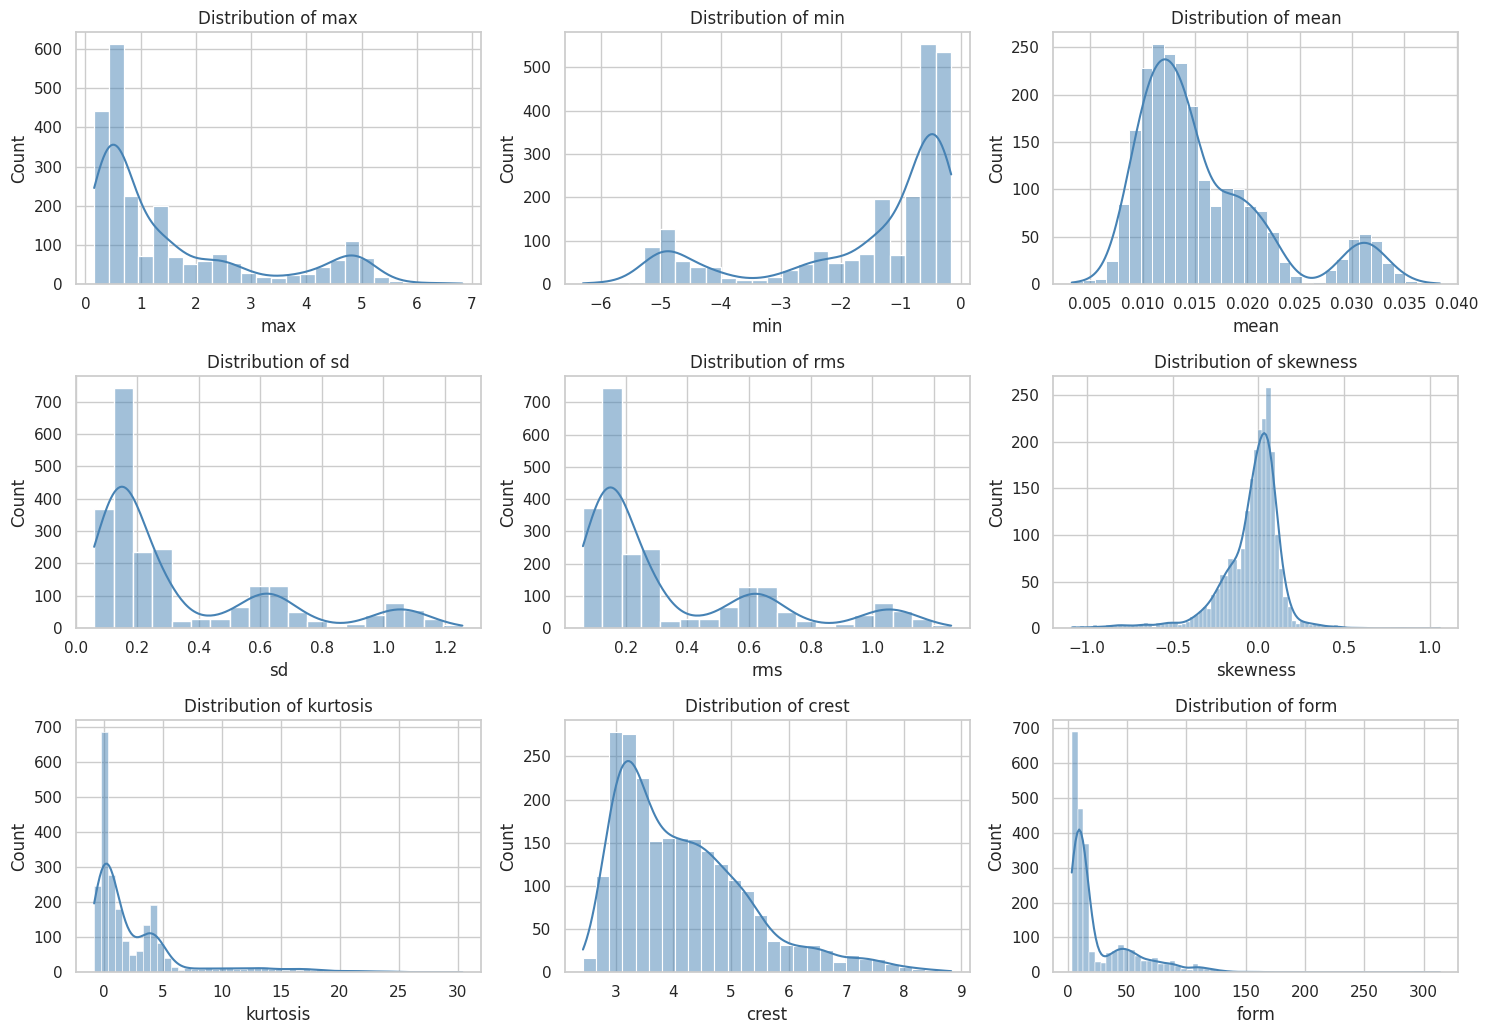

In [8]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 2.3 Feature spread by fault class

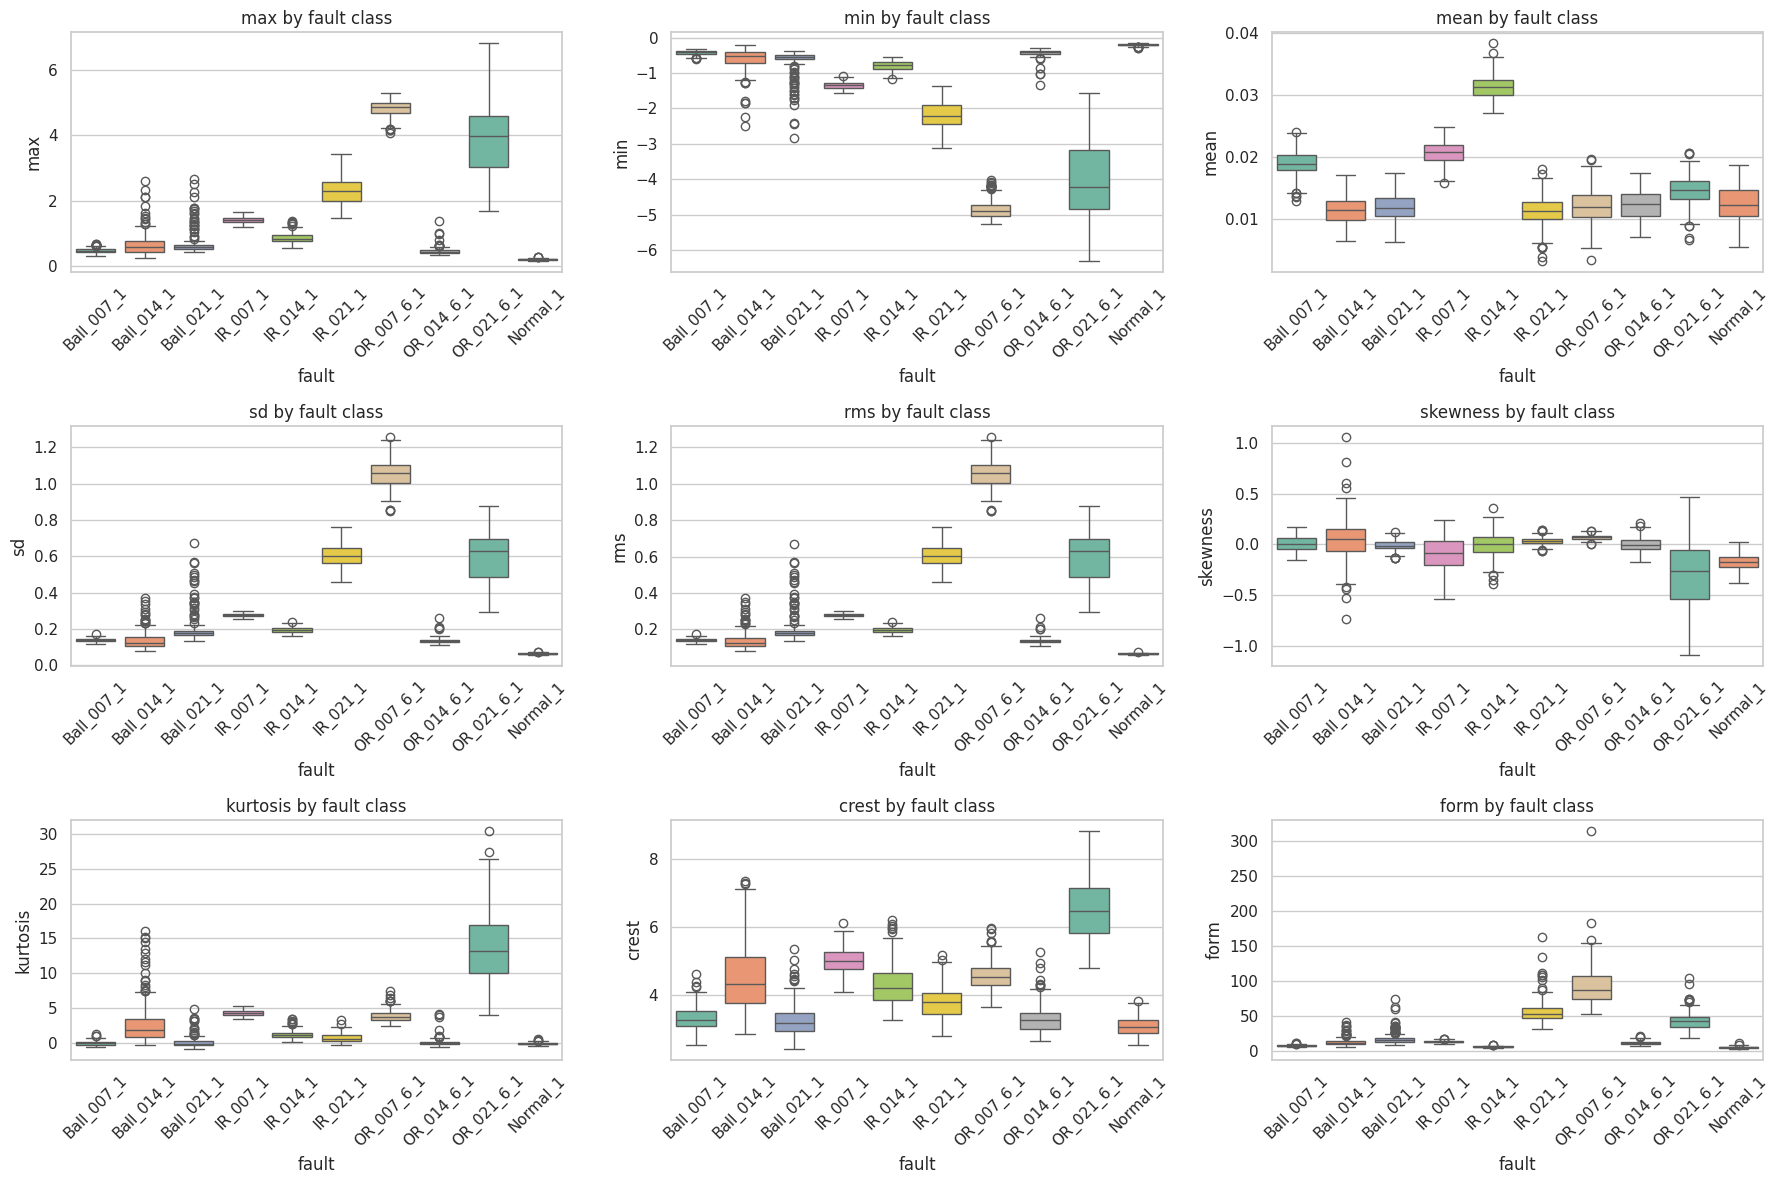

In [9]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=TARGET_COLUMN, y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} by fault class")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 2.4 Correlation between features

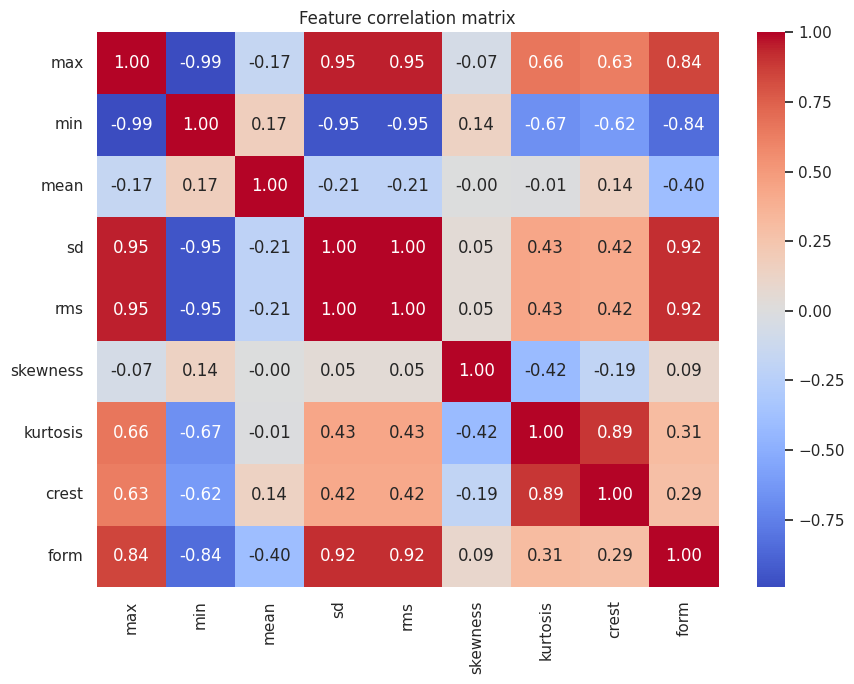

In [10]:
plt.figure(figsize=(9, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


## 3. Prepare data for machine learning

- Encode the text fault labels as numbers
- Split into train/test sets (stratified, so each fault class is represented proportionally)
- Scale the features (important for models like Logistic Regression, KNN and SVM)


In [11]:
X = df[numeric_cols].copy()
y_raw = df[TARGET_COLUMN].copy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_
print("Classes:", list(class_names))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Classes: ['Ball_007_1', 'Ball_014_1', 'Ball_021_1', 'IR_007_1', 'IR_014_1', 'IR_021_1', 'Normal_1', 'OR_007_6_1', 'OR_014_6_1', 'OR_021_6_1']
Train shape: (1725, 9) Test shape: (575, 9)


## 4. Try several supervised learning models

We train a handful of common classifiers with default-ish settings and compare them
on the held-out test set using **accuracy** and **weighted F1-score** (F1 is a better
measure than accuracy when classes are imbalanced).


In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1 (weighted)": f1_score(y_test, preds, average="weighted"),
        "Precision (weighted)": precision_score(y_test, preds, average="weighted"),
        "Recall (weighted)": recall_score(y_test, preds, average="weighted"),
    })

results_df = pd.DataFrame(results).sort_values("F1 (weighted)", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,F1 (weighted),Precision (weighted),Recall (weighted)
0,Gradient Boosting,0.951304,0.951308,0.952882,0.951304
1,Random Forest,0.947826,0.947648,0.949134,0.947826
2,Decision Tree,0.935652,0.935363,0.937602,0.935652
3,K-Nearest Neighbors,0.923478,0.922700,0.927791,0.923478
4,SVM (RBF),0.920000,0.918442,0.929899,0.920000
5,Logistic Regression,0.913043,0.911333,0.913232,0.913043


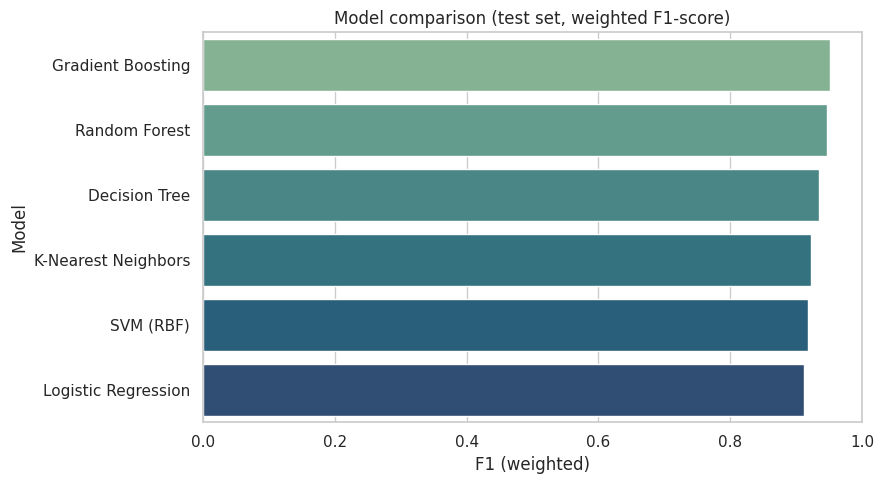

In [13]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="F1 (weighted)", y="Model", palette="crest")
plt.title("Model comparison (test set, weighted F1-score)")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


## 5. Pick the best model and validate it with k-fold cross-validation

We take the model with the highest weighted F1-score above and re-evaluate it more
rigorously using **5-fold stratified cross-validation** on the full training data.
This gives a more trustworthy estimate of how well the model generalizes, instead of
relying on a single train/test split.


In [14]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"Best model based on test F1-score: {best_model_name}")


Best model based on test F1-score: Gradient Boosting


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_accuracy = cross_val_score(best_model, X_train_scaled, y_train, cv=cv, scoring="accuracy")
cv_f1 = cross_val_score(best_model, X_train_scaled, y_train, cv=cv, scoring="f1_weighted")

print(f"5-Fold CV Accuracy: {cv_accuracy.mean():.4f}  (+/- {cv_accuracy.std():.4f})")
print(f"5-Fold CV F1 (weighted): {cv_f1.mean():.4f}  (+/- {cv_f1.std():.4f})")

cv_scores_df = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(len(cv_accuracy))] * 2,
    "Score": np.concatenate([cv_accuracy, cv_f1]),
    "Metric": ["Accuracy"] * len(cv_accuracy) + ["F1 (weighted)"] * len(cv_f1),
})


5-Fold CV Accuracy: 0.9617  (+/- 0.0091)
5-Fold CV F1 (weighted): 0.9618  (+/- 0.0091)


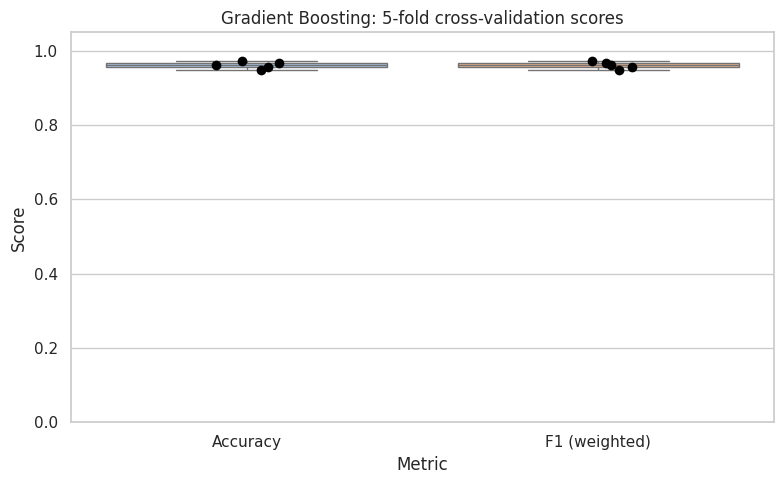

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_scores_df, x="Metric", y="Score", palette="pastel")
sns.stripplot(data=cv_scores_df, x="Metric", y="Score", color="black", size=7, jitter=True)
plt.title(f"{best_model_name}: 5-fold cross-validation scores")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 6. Final evaluation on the test set

We fit the best model on the full training set and evaluate it on the untouched test
set, with a confusion matrix and a full classification report.


In [17]:
best_model.fit(X_train_scaled, y_train)
final_preds = best_model.predict(X_test_scaled)

final_accuracy = accuracy_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds, average="weighted")

print(f"Final test accuracy: {final_accuracy:.4f}")
print(f"Final test F1 (weighted): {final_f1:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, final_preds, target_names=class_names))


Final test accuracy: 0.9513
Final test F1 (weighted): 0.9513

Classification report:
              precision    recall  f1-score   support

  Ball_007_1       0.96      0.93      0.95        57
  Ball_014_1       0.98      0.91      0.95        57
  Ball_021_1       0.87      0.79      0.83        58
    IR_007_1       1.00      0.98      0.99        58
    IR_014_1       1.00      1.00      1.00        58
    IR_021_1       0.92      1.00      0.96        57
    Normal_1       1.00      1.00      1.00        58
  OR_007_6_1       1.00      1.00      1.00        57
  OR_014_6_1       0.81      0.91      0.86        57
  OR_021_6_1       0.98      0.98      0.98        58

    accuracy                           0.95       575
   macro avg       0.95      0.95      0.95       575
weighted avg       0.95      0.95      0.95       575



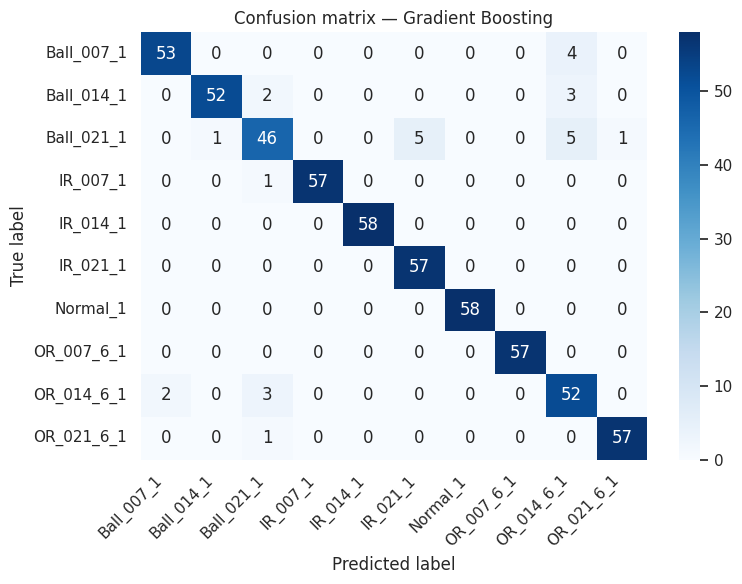

In [18]:
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion matrix — {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 6.1 Which features matter most? (if supported by the model)

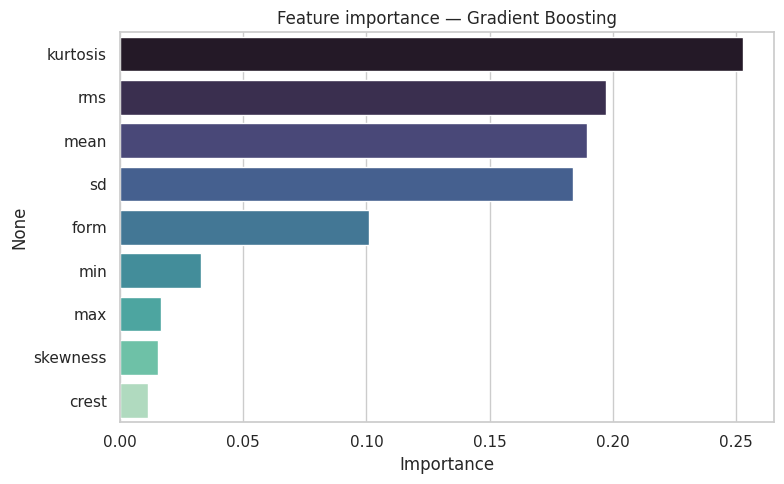

In [19]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=numeric_cols).sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, palette="mako")
    plt.title(f"Feature importance — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, "coef_"):
    coef = pd.Series(np.abs(best_model.coef_).mean(axis=0), index=numeric_cols).sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=coef.values, y=coef.index, palette="mako")
    plt.title(f"Average |coefficient| by feature — {best_model_name}")
    plt.xlabel("Average absolute coefficient")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not expose feature importances or coefficients directly.")


## 7. Summary

- **Data**: statistical vibration features (`max`, `min`, `mean`, `sd`, `rms`, `skewness`,
  `kurtosis`, `crest`, `form`) used to predict the bearing `fault` class.
- **Models tried**: Logistic Regression, K-Nearest Neighbors, Decision Tree, Random Forest,
  Gradient Boosting, and SVM (RBF kernel).
- **Best model**: printed above as `best_model_name`, selected using weighted F1-score on
  a held-out test set.
- **Validation**: the best model was re-checked with 5-fold stratified cross-validation to
  make sure its performance is consistent and not a lucky split, then evaluated one more
  time on the untouched test set (confusion matrix + classification report).
- **How to read the results**:
  - High accuracy/F1 (close to 1.0) and small standard deviation across folds → the model
    is reliable.
  - The confusion matrix shows exactly which fault classes get confused with each other —
    useful for deciding if more data or better features are needed for those specific
    classes.
  - The feature importance chart shows which vibration statistics drive the model's
    decisions the most.

Run the cell below to print a short, auto-generated recap using the actual numbers from
this run.


In [20]:
print("="*60)
print("SUMMARY")
print("="*60)
print(f"Best performing model : {best_model_name}")
print(f"Test accuracy          : {final_accuracy:.4f}")
print(f"Test F1 (weighted)     : {final_f1:.4f}")
print(f"5-fold CV accuracy     : {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})")
print(f"5-fold CV F1 (weighted): {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
print("="*60)


SUMMARY
Best performing model : Gradient Boosting
Test accuracy          : 0.9513
Test F1 (weighted)     : 0.9513
5-fold CV accuracy     : 0.9617 (+/- 0.0091)
5-fold CV F1 (weighted): 0.9618 (+/- 0.0091)
